# Investigations into the Grain Form of the Layer Above the Layer of Concern or Failure


### Grain Form of Layer Above the Layer of Concern in Pits Dug on Avalanche Crowns and Flanks

**Follow up question from Karl:**
- For all of the avalanches where the LOC is depth hoar, what crystal type is the layer immediately above the LOC? In other words, what percentage of those layers above the LOC are new snow, small facets, depth hoar, etc.?

In [207]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import seaborn as sns

from snowpyt_mechparams.snowpilot import parse_caaml_directory

color_palette = {
    'crown_weak_layer': '#6F1D1B',
    'flank_weak_layer': '#C05746',
    'crown_above_weak_layer': '#014F86',
    'flank_above_weak_layer': '#61A5C2',
    'weak_layer': '#8C2D04',
    'layer_above_weak_layer': '#2A6F97',
}



In [208]:
# helper function for distribution bar plots
def plot_grain_form_distribution(df, column, title, xlabel, *, hue=None, style_key=None):
    plot_df = df.copy()
    if column not in plot_df.columns:
        available_columns = ', '.join(map(str, plot_df.columns)) or '(no columns)'
        raise KeyError(f"Column '{column}' not found. Available columns: {available_columns}")
    plot_df[column] = plot_df[column].fillna('(no info)')
    order = plot_df[column].value_counts().index.tolist()
    plot_df[column] = pd.Categorical(plot_df[column], categories=order, ordered=True)
    bar_totals = plot_df.groupby(column, observed=False).size().reindex(order, fill_value=0)
    total_count = len(plot_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    histplot_kwargs = {'data': plot_df, 'x': column, 'ax': ax}
    if hue is not None:
        histplot_kwargs['hue'] = hue
        histplot_kwargs['multiple'] = 'stack'
        hue_order = sorted(plot_df[hue].dropna().unique())
        if hue_order:
            histplot_kwargs['hue_order'] = hue_order
        if style_key == 'weak_layer':
            histplot_kwargs['palette'] = {
                'crown': color_palette['crown_weak_layer'],
                'flank': color_palette['flank_weak_layer'],
            }
        elif style_key == 'layer_above_weak_layer':
            histplot_kwargs['palette'] = {
                'crown': color_palette['crown_above_weak_layer'],
                'flank': color_palette['flank_above_weak_layer'],
            }
    elif style_key is not None:
        histplot_kwargs['color'] = color_palette[style_key]

    sns.histplot(**histplot_kwargs)

    if hue is not None:
        for i, value in enumerate(order):
            total = int(bar_totals.loc[value])
            if total <= 0:
                continue
            pct = 100 * total / total_count if total_count else 0
            ax.annotate(
                f'{total:,} ({pct:.1f}%)',
                xy=(i, total),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=10,
            )
    elif ax.containers:
        container = ax.containers[0]
        max_h = max((patch.get_height() for patch in container.patches), default=0)
        ax.set_ylim(0, max_h * 1.32 if max_h > 0 else 1)

        labels = []
        for value in order:
            total = int(bar_totals.loc[value])
            pct = 100 * total / total_count if total_count else 0
            labels.append(f'{total:,}\n({pct:.1f}%)')
        ax.bar_label(container, labels=labels, padding=5, fontsize=10)
        ax.margins(x=0.02)

    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.set_title(f'{title} (n = {total_count:,})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    fig.tight_layout()
    plt.show()

In [209]:
# Parse all CAAML files in *data_dir* and return a list of Pit objects.
all_pits = parse_caaml_directory('data')

print(f'Loaded {len(all_pits):,} snow pits')

Loaded 50,278 snow pits


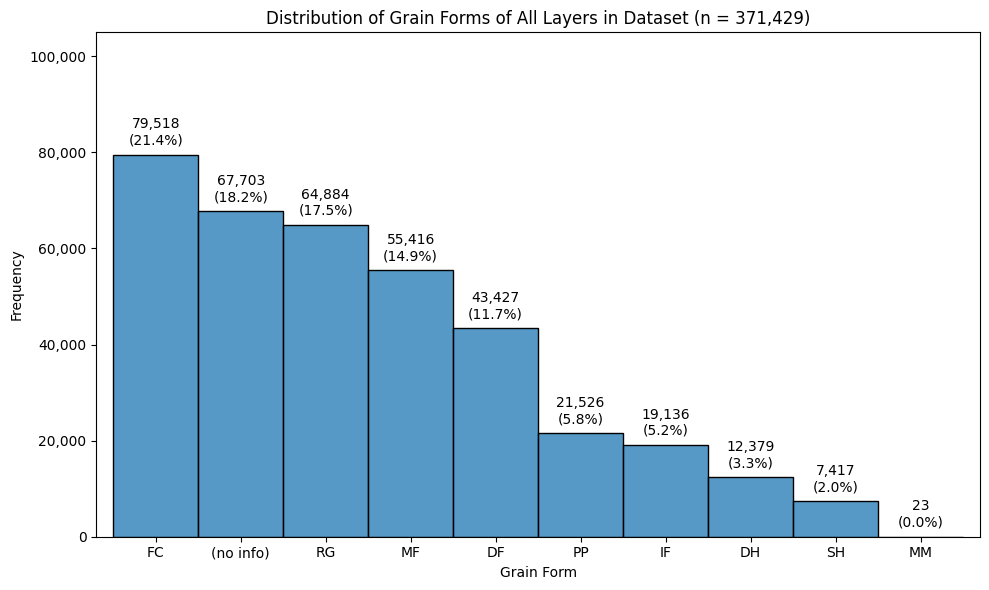

In [210]:
## Collect and plot grain form of all layers in dataset

# Collect grain form of all layers in dataset
grain_form_df = []

for pit in all_pits:
    for i, layer in enumerate(pit.snow_profile.layers):
        grain_form = getattr(layer, "grain_form_primary", None)
    
        grain_form_df.append({
            'pit_id': pit.core_info.pit_id,
            'layer_idx': i,
            'grain_form': getattr(grain_form, "basic_grain_class_code", None) if grain_form else None
        })

grain_form_df = pd.DataFrame(grain_form_df)

# Plot distribution of grain form of all layers in dataset
plot_grain_form_distribution(
    grain_form_df,
    'grain_form',
    'Distribution of Grain Forms of All Layers in Dataset',
    'Grain Form',
)


**For pits dug on avalanche crowns and flanks, what is the grain form of the layer of concern?**
- What is the distribution of grain forms
- How often is the grain for Depth Hoar (DH)? 

In [211]:
# Filter to pits dug on avalanche crowns and flanks
crown_and_flank_pits = []

for pit in all_pits:
    if pit.core_info.location.pit_near_avalanche_location == 'crown' or pit.core_info.location.pit_near_avalanche_location == 'flank':
        crown_and_flank_pits.append(pit)

print(f'Pits on avalanche crown or flank: {len(crown_and_flank_pits)}')

Pits on avalanche crown or flank: 1194


In [212]:
# Filter to pits where the layer of concern is depth hoar
crown_and_flank_pits_dh = []

for pit in crown_and_flank_pits:
    loc = pit.snow_profile.layer_of_concern # layer of concern
    gfp = getattr(loc, "grain_form_primary", None) if loc is not None else None # get primary grain form of LOC
    if gfp and gfp.basic_grain_class_code == 'DH':
        crown_and_flank_pits_dh.append(pit)

print(f'Pits with DH LOC: {len(crown_and_flank_pits_dh)}')


Pits with DH LOC: 82


In [213]:
# Extract grain form of layer above layer of concern

grain_form_above_dh = []

for pit in crown_and_flank_pits_dh:

    # Pit info
    pit_id = pit.core_info.pit_id
    pit_near_avalanche_location = pit.core_info.location.pit_near_avalanche_location

    # Get index of layer of concern
    loc_idx = None
    for i, layer in enumerate(pit.snow_profile.layers):
        if layer.layer_of_concern:
            loc_idx = i # index of layer of concern
            break
    if loc_idx is None or loc_idx == 0:
        grain_form_above_dh[pit.core_info.pit_id] = None
        continue

    above = pit.snow_profile.layers[loc_idx - 1] # layer above LOC
    gfp = getattr(above, "grain_form_primary", None) # grain form of layer above LOC

    # Record pit and grain form of layer above LOC
    info = {
        'pit_id': pit_id,
        'pit_near_avalanche_location': pit_near_avalanche_location,
        'grain_form_above_loc': gfp.basic_grain_class_code if gfp is not None else None
    }
    grain_form_above_dh.append(info)


grain_form_above_dh_df = pd.DataFrame(grain_form_above_dh)

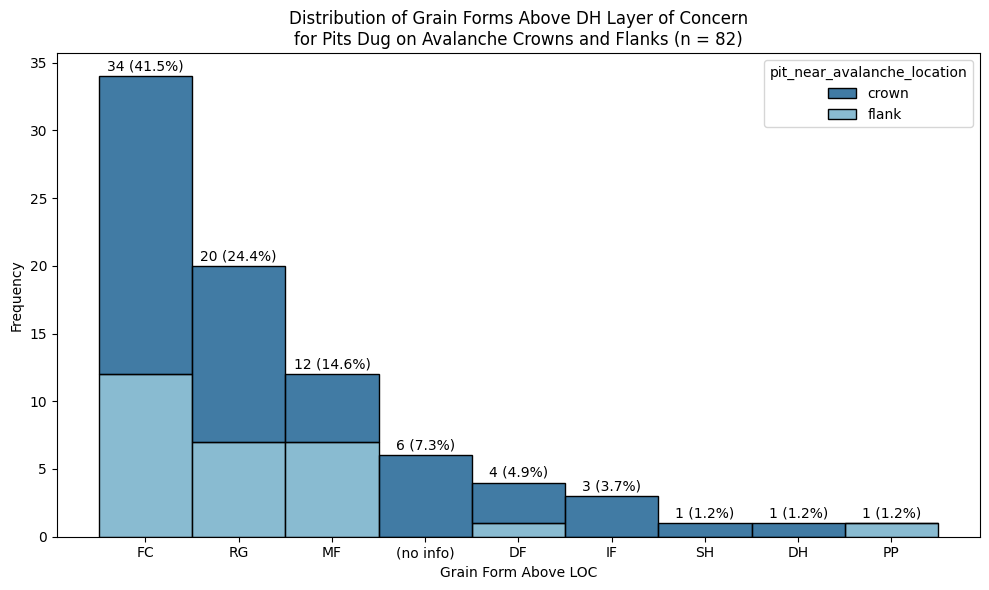

In [214]:
# Plot the frequency of grain forms above DH LOC, stacked by crown/flank
plot_grain_form_distribution(
    grain_form_above_dh_df,
    'grain_form_above_loc',
    'Distribution of Grain Forms Above DH Layer of Concern\nfor Pits Dug on Avalanche Crowns and Flanks',
    'Grain Form Above LOC',
    hue='pit_near_avalanche_location',
    style_key='layer_above_weak_layer',
)

### ECT: Grain Form of Layer Above the Layer of Failure for ECTP results

- For all ECTs where the LOC is depth hoar, and that propagate completely across the column (ECTPs), what crystal type is the layer immediately above the LOC?

In [215]:
ECTP_results = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    for ECT in pit.stability_tests.ECT:
        # Check if the ECT is an ECTP
        ECTP = False

        if hasattr(ECT, "propagation") and ECT.propagation:
            ECTP = True
        elif hasattr(ECT, "test_score") and ECT.test_score and "ECTP" in str(ECT.test_score):
            ECTP = True

        if not ECTP:
            continue # If the ECT is not an ECTP, skip

        # Get failure depth
        failure_depth = ECT.depth_top[0] if ECT.depth_top is not None and len(ECT.depth_top) else None

        # Initialize matching boolean
        layer_matched = False # Whether the failure depth was matched to a snow profile layer

        if failure_depth is not None:
            # Iterate through the snow profile layers to find the layer that contains the failure depth
            for i, layer in enumerate(layers):
                depth_top = layer.depth_top[0] if layer.depth_top is not None and len(layer.depth_top) else None
                layer_thickness = layer.thickness[0] if layer.thickness is not None and len(layer.thickness) else None
                depth_bottom = depth_top + layer_thickness

                if depth_top <= failure_depth < depth_bottom: # If the failure depth is within the layer
                    layer_matched = True
                    failure_layer = layer
                    failure_layer_idx = i
                    break

        # Grain forms only when a layer matched and it is not the top snow layer.
        if not layer_matched or failure_layer_idx == 0: # If the failure depth was not matched to a layer or if it is the top snow layer
            grain_form_failure_layer = None
            grain_form_layer_above_failure_layer = None
        else: # If the failure depth was matched to a layer and it is not the top snow layer
            grain_form_failure_layer = getattr(failure_layer, "grain_form_primary", None) if failure_layer is not None else None
            layer_above_failure_layer = layers[failure_layer_idx - 1]
            grain_form_layer_above_failure_layer = getattr(layer_above_failure_layer, "grain_form_primary", None) if layer_above_failure_layer is not None else None

        ECTP_result_info = {
            'pit_id': pit.core_info.pit_id,
            'ECTP_test_score': ECT.test_score,
            'layer_matched': layer_matched,
            'matched_layer_idx': failure_layer_idx,
            'ECTP_num_taps': ECT.num_taps,
            'grain_form_failure_layer': getattr(grain_form_failure_layer, 'basic_grain_class_code', None) if grain_form_failure_layer is not None else None,
            'grain_form_layer_above_failure_layer': getattr(grain_form_layer_above_failure_layer, 'basic_grain_class_code', None) if grain_form_layer_above_failure_layer is not None else None,
        }

        ECTP_results.append(ECTP_result_info)

ECTP_results_df = pd.DataFrame(ECTP_results)


In [216]:
total_ectp_results = len(ECTP_results_df)
total_matched_results = len(ECTP_results_df[ECTP_results_df['layer_matched'] == True])
matched_on_top_layer = ECTP_results_df[
    ECTP_results_df["layer_matched"] & (ECTP_results_df["matched_layer_idx"] == 0)
]
total_for_analysis = total_matched_results - len(matched_on_top_layer)

print(f'Total ECTP results: {total_ectp_results}')
print(f'Total matched results: {total_matched_results}')
print(f'Pits matched on top layer: {len(matched_on_top_layer)}')
print("--------------------------------")
print(f'Total for analysis: {total_for_analysis}')


Total ECTP results: 15256
Total matched results: 14973
Pits matched on top layer: 197
--------------------------------
Total for analysis: 14776


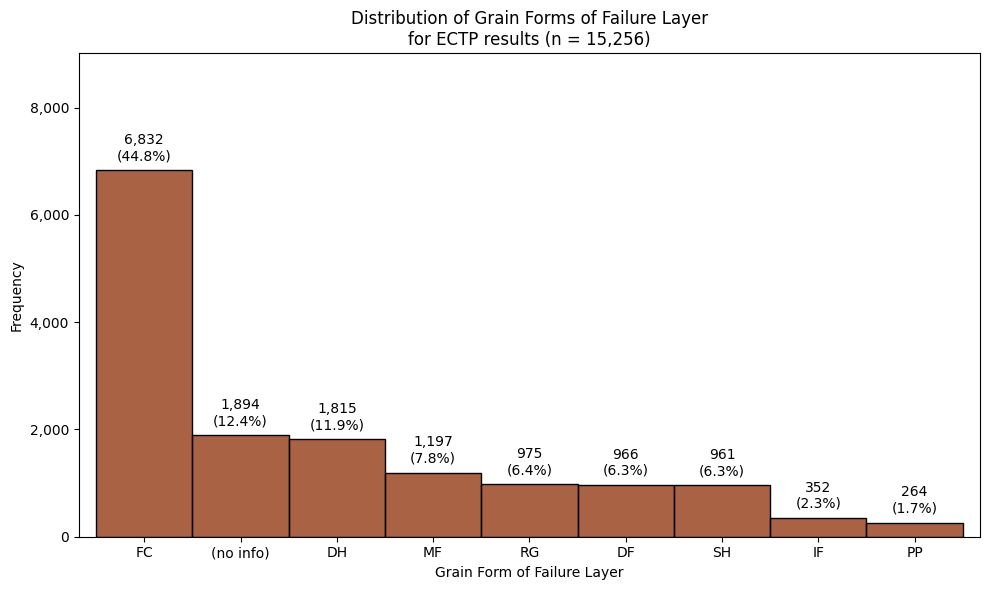

In [217]:
## Plot distribution of grain form of failure layer

plot_grain_form_distribution(
    ECTP_results_df,
    'grain_form_failure_layer',
    'Distribution of Grain Forms of Failure Layer\nfor ECTP results',
    'Grain Form of Failure Layer',
    style_key='weak_layer',
)


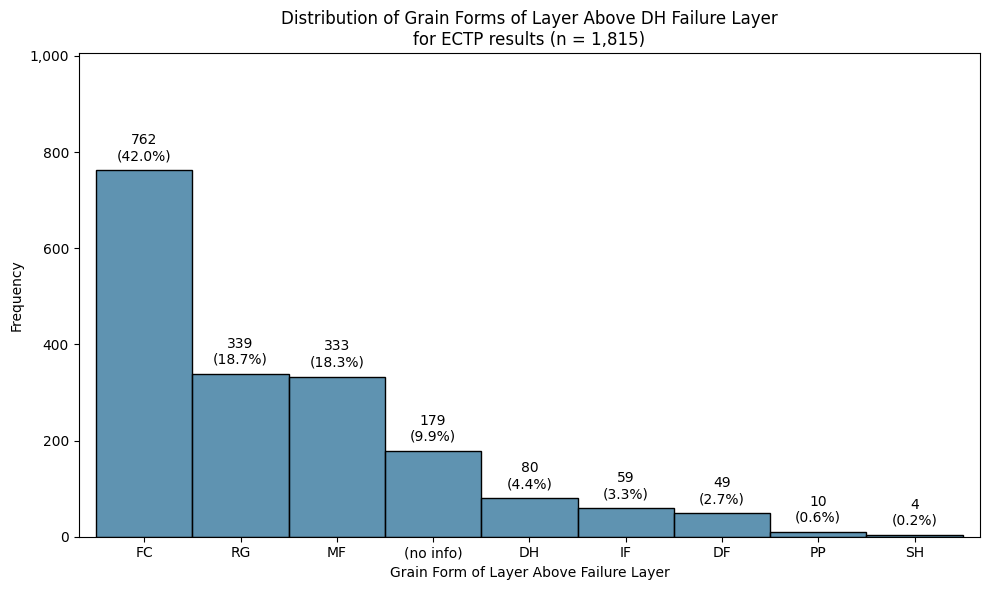

In [218]:
## Plot distribution of grain form of layer above failure layer where the failure layer is depth hoar

# Filter to ECTP results where the failure layer is depth hoar
ectp_results_dh = ECTP_results_df[ECTP_results_df['grain_form_failure_layer'] == 'DH']

# Plot distribution of grain form of layer above failure layer

plot_grain_form_distribution(
    ectp_results_dh,
    'grain_form_layer_above_failure_layer',
    'Distribution of Grain Forms of Layer Above DH Failure Layer\nfor ECTP results',
    'Grain Form of Layer Above Failure Layer',
    style_key='layer_above_weak_layer',
)

### PST:

- For all PSTs where the LOC is depth hoar, and that propagate to END with a cut length less than 30 cm, what crystal type is the layer immediately above the LOC? 

In [219]:
PST_results = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    for PST in pit.stability_tests.PST:

        match_condition = False

        # Get cut depth
        cut_depth = getattr(PST, "depth_top", None)
        cut_depth_val = cut_depth[0] if cut_depth is not None and len(cut_depth) else None

        # Get cut length
        cut_length = getattr(PST, "cut_length", None)
        cut_length_val = cut_length[0] if cut_length is not None and len(cut_length) else None

        # Get fracture propagation
        fracture_prop = getattr(PST, "fracture_prop", None)

        if fracture_prop == "End" and cut_length_val < 30: # If the test propogates to END with a cut length less than 30 cm
            match_condition = True

        if not match_condition:
            continue

        # Match to layer in snow profile

        # Initialize matching boolean
        layer_matched = False # Whether the failure depth was matched to a snow profile layer
        failure_layer_idx = None

        if cut_depth_val is not None:
            # Iterate through the snow profile layers to find the layer that contains the failure depth
            for i, layer in enumerate(layers):
                depth_top = layer.depth_top[0] if layer.depth_top is not None and len(layer.depth_top) else None
                layer_thickness = layer.thickness[0] if layer.thickness is not None and len(layer.thickness) else None
                depth_bottom = depth_top + layer_thickness

                if depth_top <= cut_depth_val < depth_bottom: # If the cut depth is within the layer
                    layer_matched = True
                    failure_layer = layer
                    failure_layer_idx = i
                    break

        # Grain forms only when a layer matched and it is not the top snow layer.
        if not layer_matched or failure_layer_idx == 0: # If the failure depth was not matched to a layer or if it is the top snow layer
            grain_form_cut_layer = None
            grain_form_layer_above_cut_layer = None
        else: # If the failure depth was matched to a layer and it is not the top snow layer
            grain_form_cut_layer = getattr(failure_layer, "grain_form_primary", None) if failure_layer is not None else None
            layer_above_cut_layer = layers[failure_layer_idx - 1]
            grain_form_layer_above_cut_layer = getattr(layer_above_cut_layer, "grain_form_primary", None) if layer_above_cut_layer is not None else None

        PST_result_info = {
            'pit_id': pit.core_info.pit_id,
            'cut_depth': cut_depth_val,
            'cut_length': cut_length_val,
            'fracture_prop': fracture_prop,
            'layer_matched': layer_matched,
            'matched_layer_idx': failure_layer_idx,
            'grain_form_cut_layer': getattr(grain_form_cut_layer, 'basic_grain_class_code', None) if grain_form_cut_layer is not None else None,
            'grain_form_layer_above_cut_layer': getattr(grain_form_layer_above_cut_layer, 'basic_grain_class_code', None) if grain_form_layer_above_cut_layer is not None else None,
        }

        PST_results.append(PST_result_info)

PST_results_df = pd.DataFrame(PST_results)


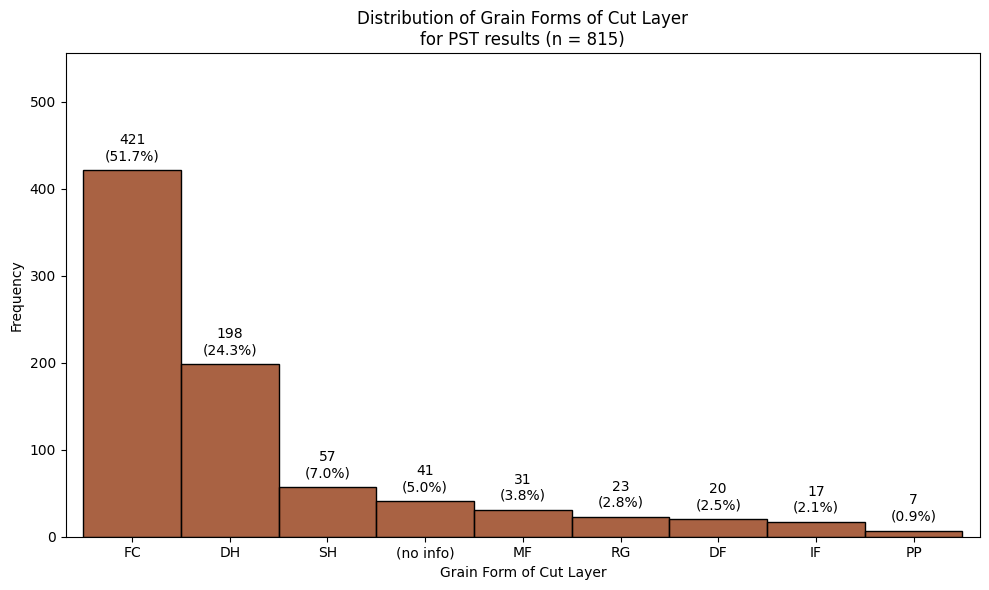

In [220]:
# Plot distribution of grain forms of cut layer

plot_grain_form_distribution(
    PST_results_df,
    'grain_form_cut_layer',
    'Distribution of Grain Forms of Cut Layer\nfor PST results',
    'Grain Form of Cut Layer',
    style_key='weak_layer',
)

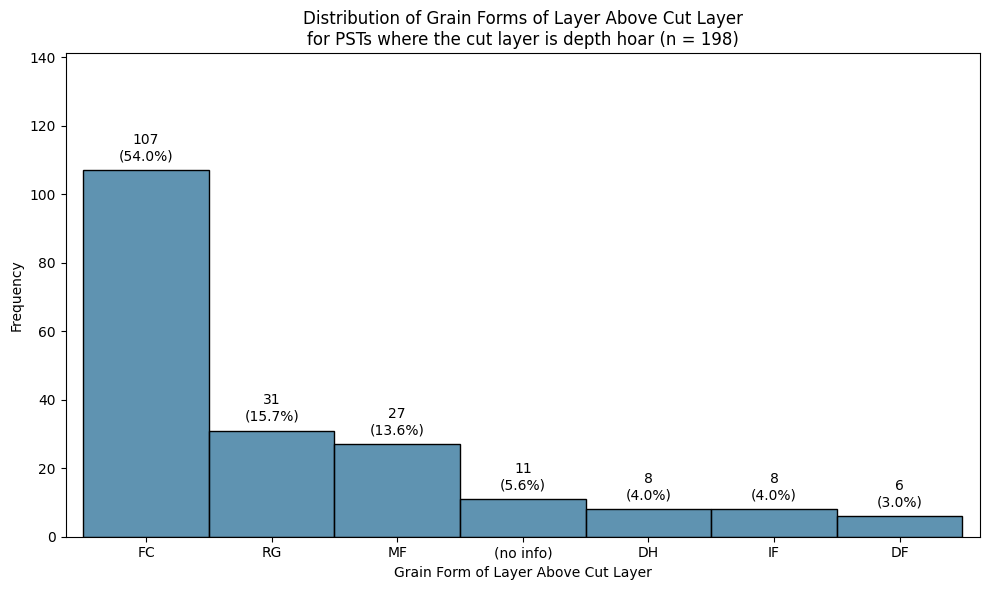

In [221]:
# Filter to PSTs where the cut layer is depth hoar
pst_results_dh = PST_results_df[PST_results_df['grain_form_cut_layer'] == 'DH']

# Plot distribution of grain forms of layer above cut layer

plot_grain_form_distribution(
    pst_results_dh,
    'grain_form_layer_above_cut_layer',
    'Distribution of Grain Forms of Layer Above Cut Layer\nfor PSTs where the cut layer is depth hoar',
    'Grain Form of Layer Above Cut Layer',
    style_key='layer_above_weak_layer',
)

